# CLUSTERING ANALYSIS 

## Objective:
The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.

## Data Preprocessing:
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.	Use multiple visualizations to understand the hidden patterns in the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_excel("EastWestAirlines.xlsx",sheet_name=1)

In [3]:
df.head(7)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
5,6,16420,0,1,1,1,0,0,0,0,6942,0
6,7,84914,0,3,1,1,27482,25,0,0,6994,0


In [4]:
df.shape

(3999, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [7]:
stats = pd.DataFrame({
    'Mean' : df.mean(),
    'Median' : df.median(),
    'Mode' : df.mode().iloc[0],
    'Min' : df.min(),
    'Max' : df.max(),
    'Q1' : df.quantile(0.25),
    'Q2' : df.quantile(0.50),
    'Q3' : df.quantile(0.75),
    'IQR' : df.quantile(0.75) - df.quantile(0.25),
    'Missing Values' : df.isnull().sum()
})
stats

,Mean,Median,Mode,Min,Max,Q1,Q2,Q3,IQR,Missing Values
ID#,2014.819455,2016.0,1.0,1,4021,1010.5,2016.0,3020.5,2010.0,0
Balance,73601.327582,43097.0,1000.0,0,1704838,18527.5,43097.0,92404.0,73876.5,0
Qual_miles,144.114529,0.0,0.0,0,11148,0.0,0.0,0.0,0.0,0
cc1_miles,2.059515,1.0,1.0,1,5,1.0,1.0,3.0,2.0,0
cc2_miles,1.014504,1.0,1.0,1,3,1.0,1.0,1.0,0.0,0
cc3_miles,1.012253,1.0,1.0,1,5,1.0,1.0,1.0,0.0,0
Bonus_miles,17144.846212,7171.0,0.0,0,263685,1250.0,7171.0,23800.5,22550.5,0
Bonus_trans,11.601900,12.0,0.0,0,86,3.0,12.0,17.0,14.0,0
Flight_miles_12mo,460.055764,0.0,0.0,0,30817,0.0,0.0,311.0,311.0,0
Flight_trans_12,1.373593,0.0,0.0,0,53,0.0,0.0,1.0,1.0,0


In [8]:
df.corr()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,1.000000,-0.243737,-0.019374,-0.224465,0.020291,-0.014707,-0.203012,-0.146915,-0.031013,-0.052096,-0.964988,-0.177901
Balance,-0.243737,1.000000,0.108722,0.338344,-0.008804,0.035243,0.403487,0.324935,0.217551,0.255700,0.263129,0.178494
Qual_miles,-0.019374,0.108722,1.000000,0.007931,-0.013923,-0.007779,0.031021,0.050725,0.126774,0.144004,0.017312,0.095256
cc1_miles,-0.224465,0.338344,0.007931,1.000000,-0.068223,0.060555,0.825200,0.608943,0.037370,0.041333,0.230849,0.335457
cc2_miles,0.020291,-0.008804,-0.013923,-0.068223,1.000000,-0.006166,-0.003969,0.064399,0.010598,0.028284,-0.005807,0.005332
cc3_miles,-0.014707,0.035243,-0.007779,0.060555,-0.006166,1.000000,0.204134,0.097313,-0.001777,-0.001117,0.010832,0.023484
Bonus_miles,-0.203012,0.403487,0.031021,0.825200,-0.003969,0.204134,1.000000,0.603180,0.183536,0.185261,0.210397,0.373506
Bonus_trans,-0.146915,0.324935,0.050725,0.608943,0.064399,0.097313,0.603180,1.000000,0.377216,0.432364,0.161262,0.333893
Flight_miles_12mo,-0.031013,0.217551,0.126774,0.037370,0.010598,-0.001777,0.183536,0.377216,1.000000,0.869193,0.037271,0.217715
Flight_trans_12,-0.052096,0.255700,0.144004,0.041333,0.028284,-0.001117,0.185261,0.432364,0.869193,1.000000,0.059260,0.247909


In [9]:
df.nunique()

ID#                  3999
Balance              3904
Qual_miles            164
cc1_miles               5
cc2_miles               3
cc3_miles               5
Bonus_miles          2734
Bonus_trans            57
Flight_miles_12mo     343
Flight_trans_12        35
Days_since_enroll    2820
Award?                  2
dtype: int64

In [10]:
df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [11]:
features = [
    'Balance',
    'Qual_miles',
    'cc1_miles',
    'cc2_miles',
    'cc3_miles',
    'Bonus_miles',
    'Bonus_trans',
    'Flight_miles_12mo',
    'Flight_trans_12',
    'Days_since_enroll'
]
X = df[features].copy()
X.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,28143,0,1,1,1,174,1,0,0,7000
1,19244,0,1,1,1,215,2,0,0,6968
2,41354,0,1,1,1,4123,4,0,0,7034
3,14776,0,1,1,1,500,1,0,0,6952
4,97752,0,4,1,1,43300,26,2077,4,6935


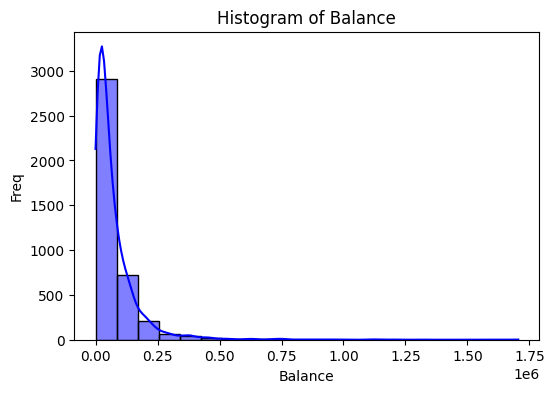

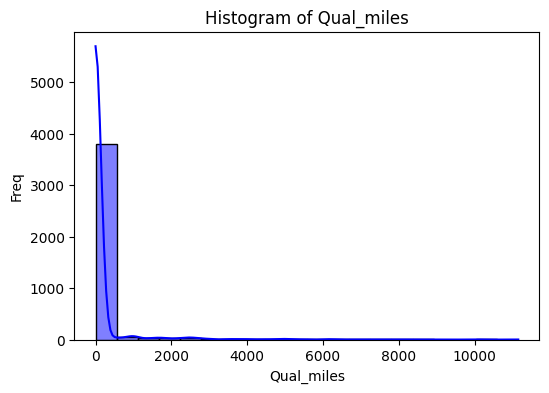

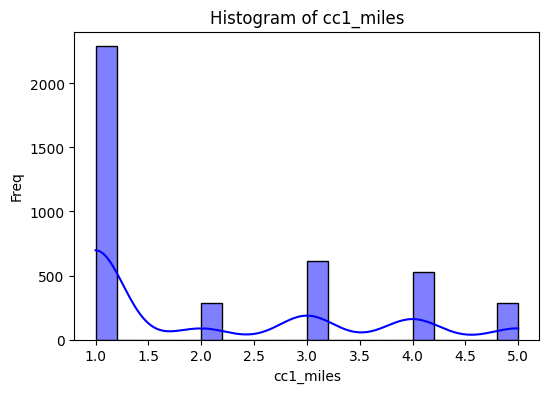

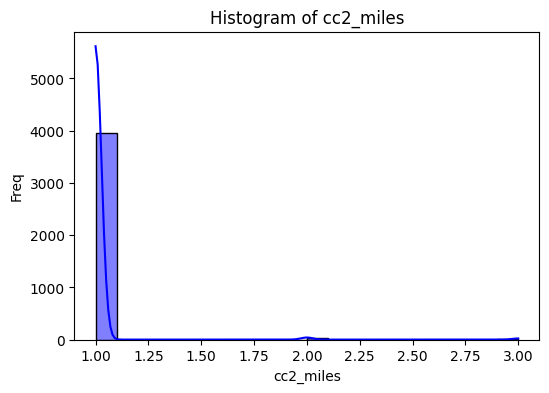

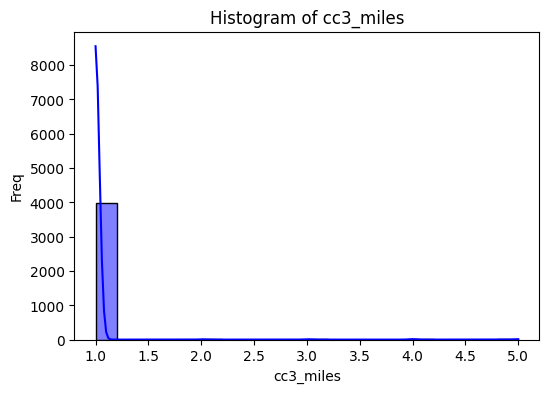

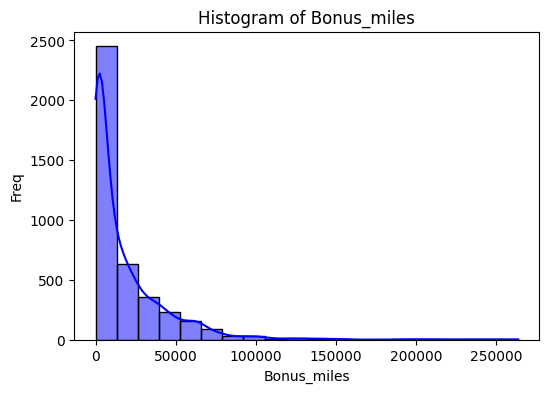

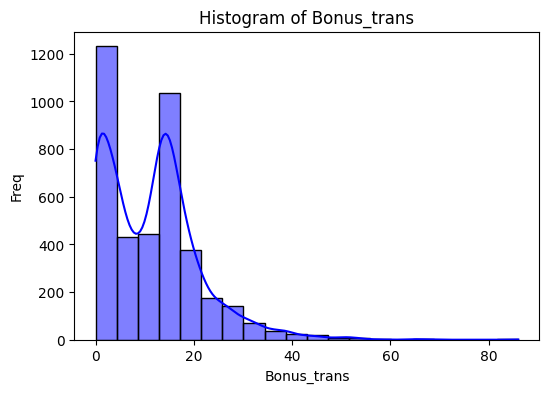

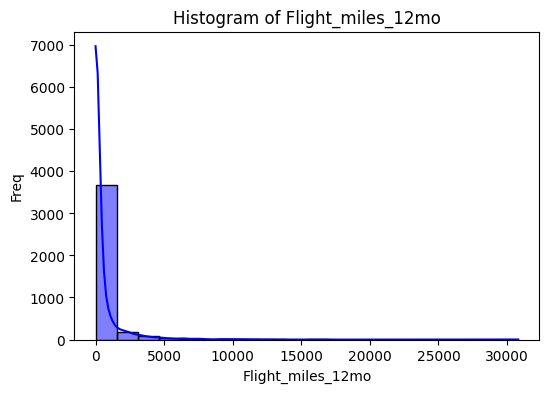

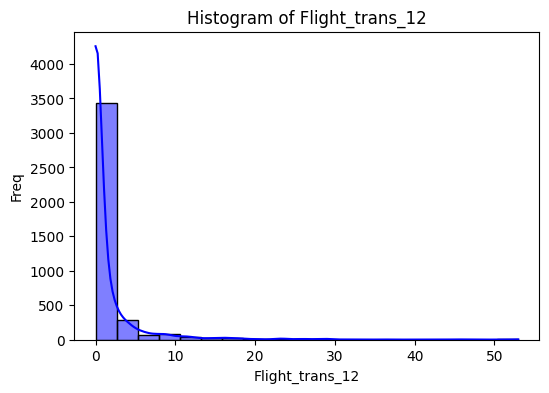

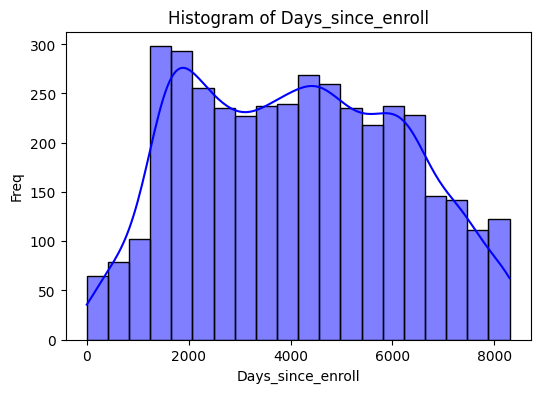

In [12]:
for col in X:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='Blue', edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Freq")
    plt.show()

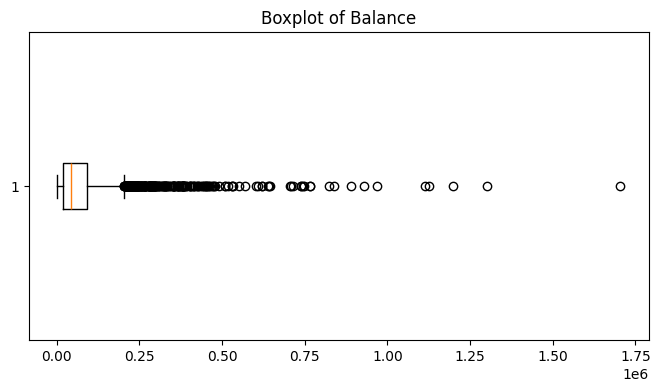

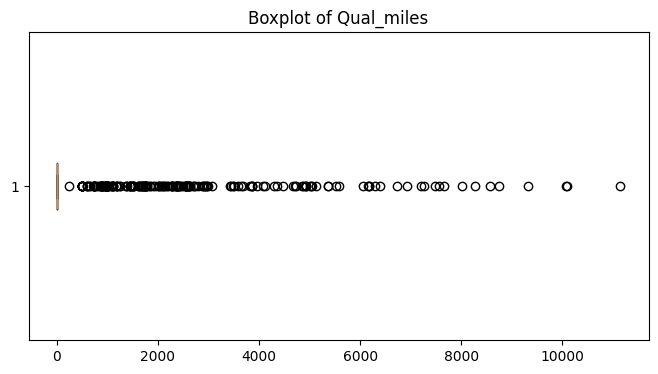

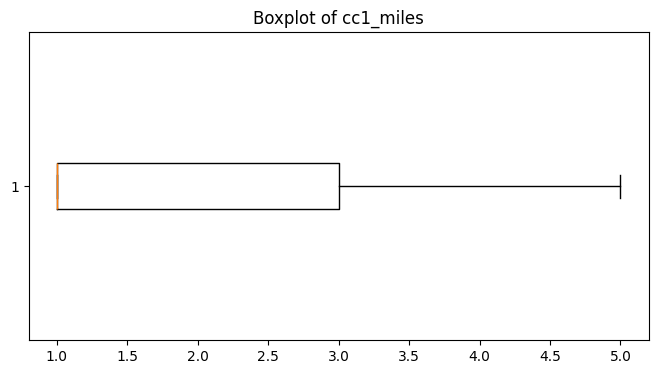

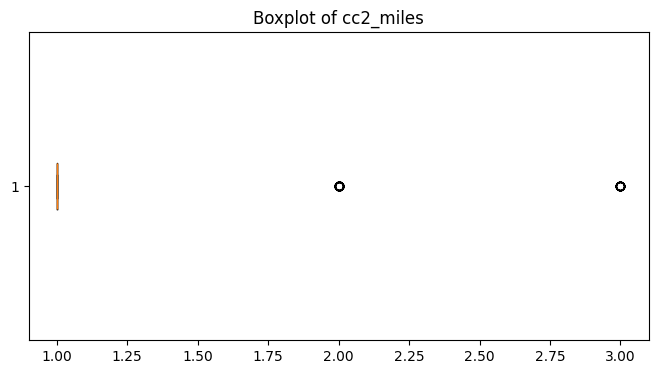

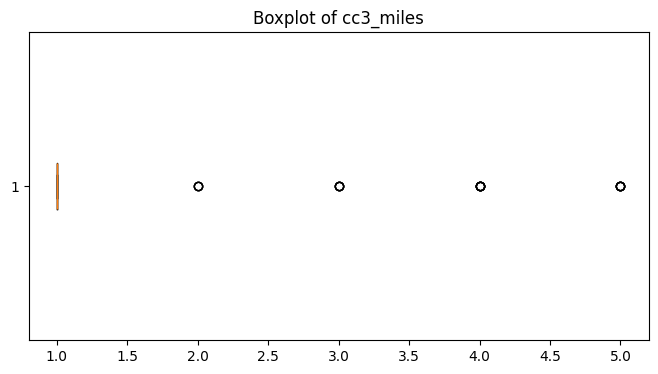

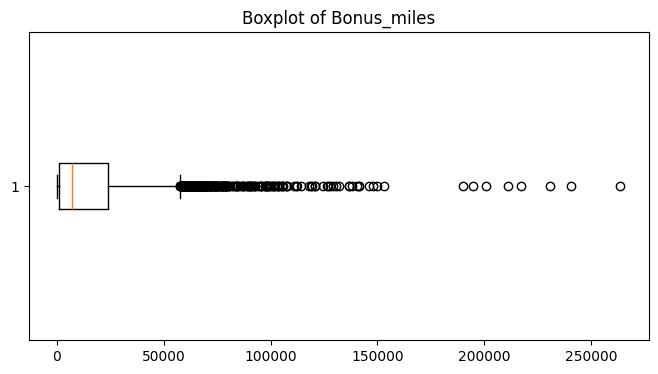

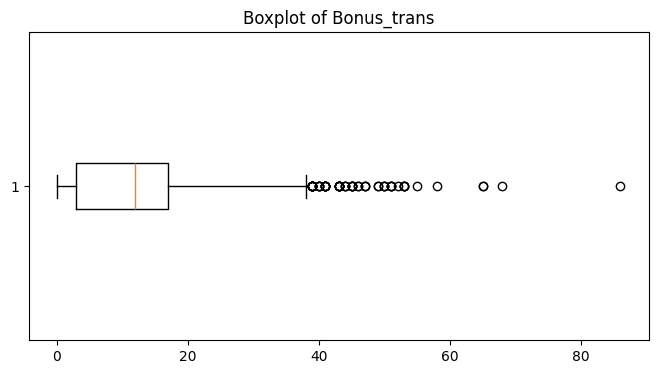

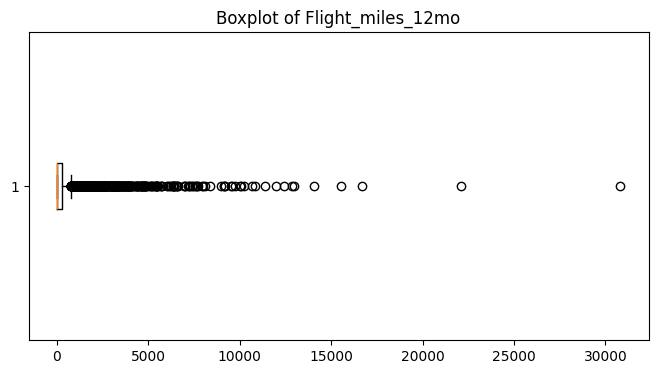

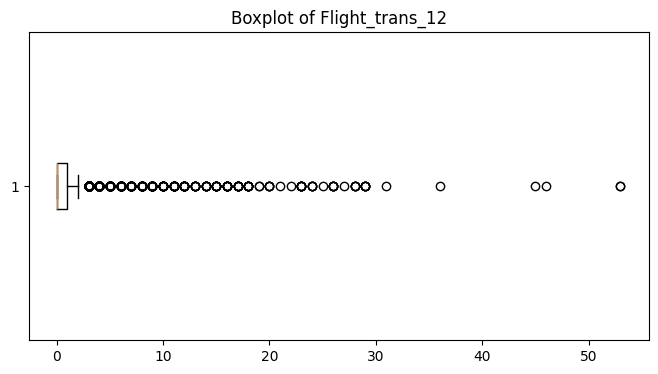

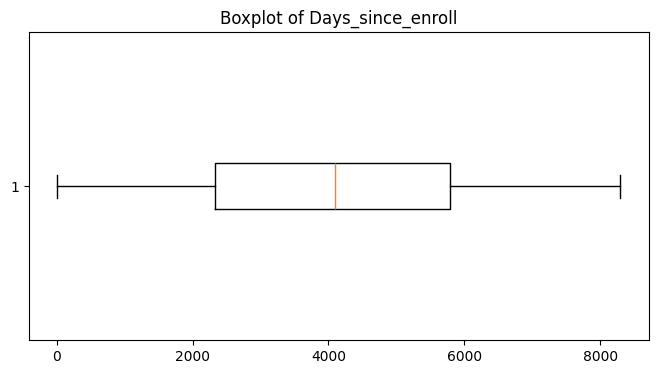

In [13]:
for col in X:
    plt.figure(figsize=(8,4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

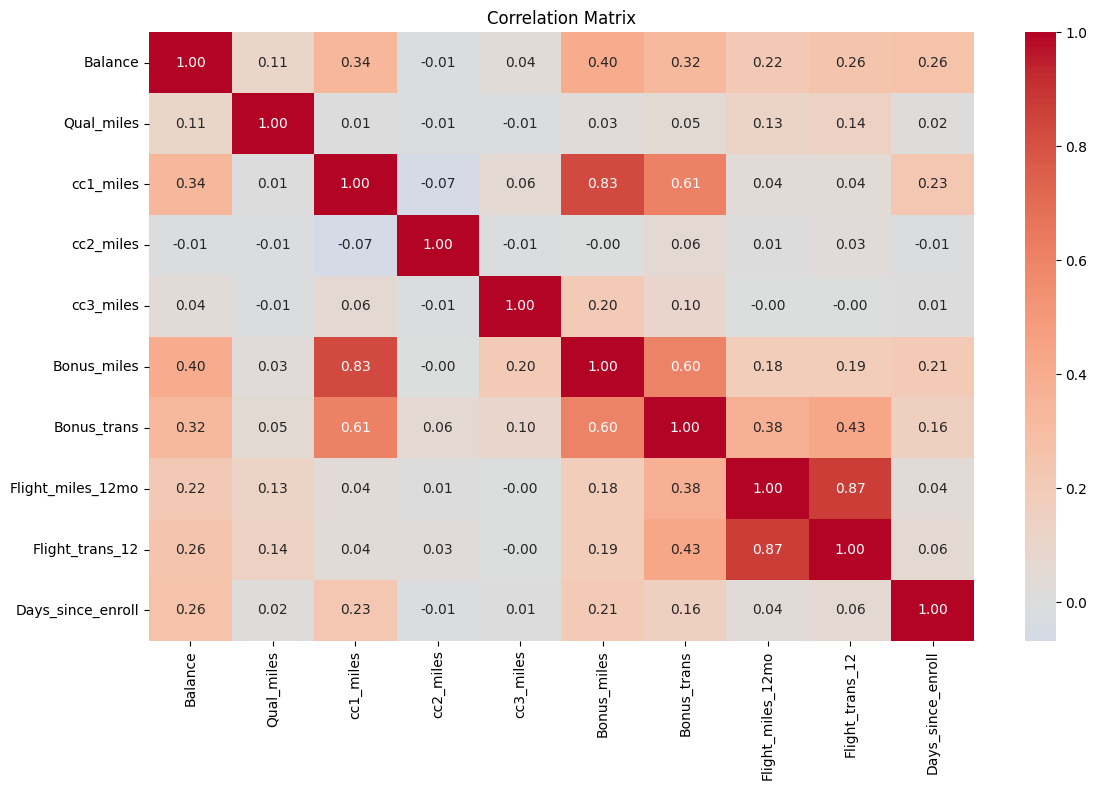

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    X.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [15]:
X_clean = X.copy()
mask = pd.Series(True, index=X_clean.index)
for column in X_clean.columns:
    Q1 = X_clean[column].quantile(0.25)
    Q3 = X_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= (
        (X_clean[column] >= lower_bound) &
        (X_clean[column] <= upper_bound)
    )
X_clean = X_clean[mask].copy()
print("Original dataset shape:", X.shape)
print("After outlier removal:", X_clean.shape)
print("Rows removed:", X.shape[0] - X_clean.shape[0])

Original dataset shape: (3999, 10)
After outlier removal: (2875, 10)
Rows removed: 1124


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_clean.columns,
    index=X_clean.index
)
X_scaled.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,-0.438859,0.0,-0.719055,0.0,0.0,-0.783131,-1.081732,-0.378837,-0.409708,1.503693
1,-0.647735,0.0,-0.719055,0.0,0.0,-0.780130,-0.952735,-0.378837,-0.409708,1.488035
2,-0.128773,0.0,-0.719055,0.0,0.0,-0.494075,-0.694742,-0.378837,-0.409708,1.520330
3,-0.752607,0.0,-0.719055,0.0,0.0,-0.759268,-1.081732,-0.378837,-0.409708,1.480206
5,-0.714019,0.0,-0.719055,0.0,0.0,-0.795867,-1.210728,-0.378837,-0.409708,1.475312


## Implementing Clustering Algorithms:
-	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.
-	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
-	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

In [17]:
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

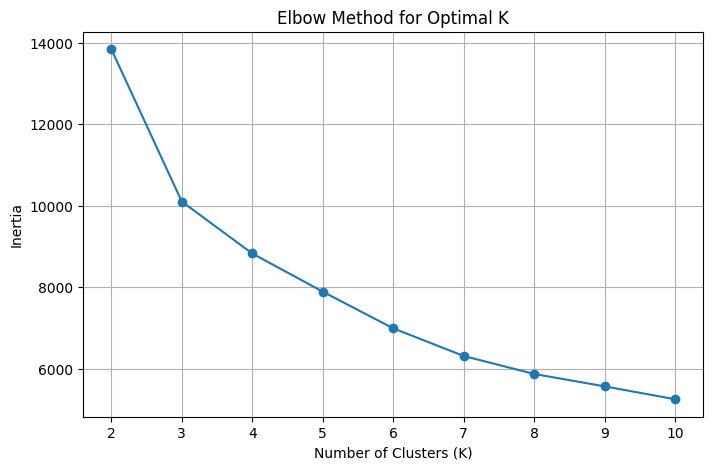

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

In [19]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [20]:
X_kmeans = X_clean.copy()
X_kmeans["Cluster"] = kmeans_labels
X_kmeans.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Cluster
0,28143,0,1,1,1,174,1,0,0,7000,1
1,19244,0,1,1,1,215,2,0,0,6968,1
2,41354,0,1,1,1,4123,4,0,0,7034,1
3,14776,0,1,1,1,500,1,0,0,6952,1
5,16420,0,1,1,1,0,0,0,0,6942,1


In [21]:
cluster_counts = X_kmeans["Cluster"].value_counts().sort_index()
print(cluster_counts)

Cluster
0     852
1    1659
2     364
Name: count, dtype: int64


In [22]:
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)
print("K-Means Silhouette Score:", kmeans_silhouette)

K-Means Silhouette Score: 0.37751400838368027


In [23]:
silhouette_scores = []
for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3491
K = 3, Silhouette Score = 0.3776
K = 4, Silhouette Score = 0.2717
K = 5, Silhouette Score = 0.2789
K = 6, Silhouette Score = 0.2706
K = 7, Silhouette Score = 0.2851
K = 8, Silhouette Score = 0.2822
K = 9, Silhouette Score = 0.2809
K = 10, Silhouette Score = 0.2837


In [24]:
cluster_profile = X_kmeans.groupby("Cluster")[features].mean()
cluster_profile.round(2)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
Cluster,,,,,,,,,,
0,75774.00,0.0,3.20,1.0,1.0,25076.06,16.19,6.10,0.05,4539.31
1,28083.57,0.0,1.08,1.0,1.0,2868.78,5.39,3.47,0.03,3575.22
2,64603.76,0.0,2.03,1.0,1.0,14108.71,11.65,420.76,1.30,4096.76


## Cluster Analysis and Interpretation:
- Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.
## Visualization:
- Visualize the clustering results using scatter plots or other suitable visualization techniques.
- Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.
## Evaluation and Performance Metrics:
- Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.41535705 0.25506118]
Total explained variance: 0.6704182391649203


In [26]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)
pca_df["Cluster"] = kmeans_labels

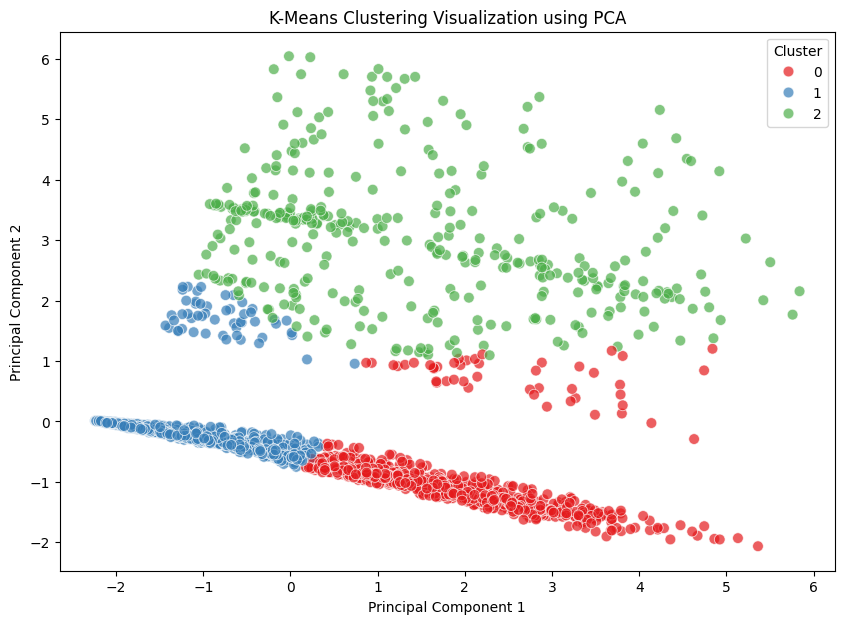

In [27]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=60,
    alpha=0.7
)
plt.title("K-Means Clustering Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [28]:
dbscan_results = []
eps_values = [
    0.6, 0.7, 0.8, 0.9,
    1.0, 1.1, 1.2, 1.3,
    1.4, 1.5
]
for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    if n_clusters >= 2:
        non_noise = labels != -1
        silhouette = silhouette_score(
            X_scaled[non_noise],
            labels[non_noise]
        )
    else:
        silhouette = np.nan
    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "silhouette_score": silhouette
    })
dbscan_results = pd.DataFrame(dbscan_results)
dbscan_results

,eps,clusters,noise_points,silhouette_score
0,0.6,11,693,0.185761
1,0.7,11,552,0.180692
2,0.8,13,455,0.189039
3,0.9,10,325,0.079171
4,1.0,8,244,0.215254
5,1.1,3,206,0.331485
6,1.2,6,151,0.262936
7,1.3,4,123,0.330590
8,1.4,5,88,0.324102
9,1.5,4,56,0.323308


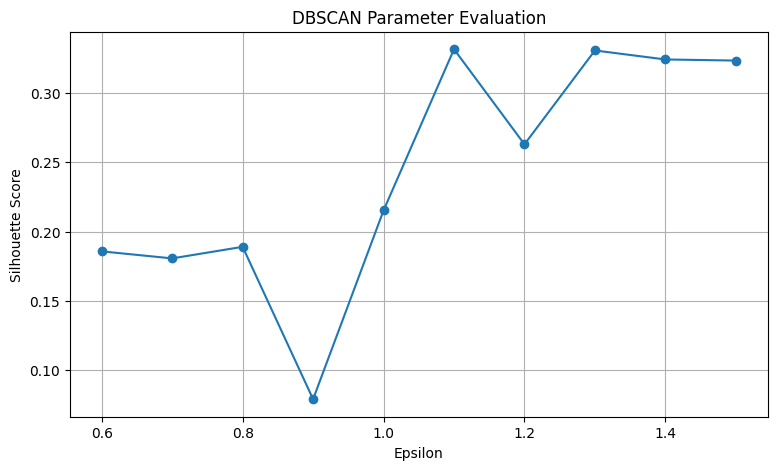

In [29]:
plt.figure(figsize=(9, 5))
plt.plot(
    dbscan_results["eps"],
    dbscan_results["silhouette_score"],
    marker="o"
)
plt.xlabel("Epsilon")
plt.ylabel("Silhouette Score")
plt.title("DBSCAN Parameter Evaluation")
plt.grid(True)
plt.show()

In [30]:
dbscan = DBSCAN(
    eps=1.1,
    min_samples=5
)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [31]:
X_dbscan = X_clean.copy()
X_dbscan["Cluster"] = dbscan_labels
X_dbscan["Cluster"].value_counts().sort_index()

Cluster
-1     206
 0    2386
 1     256
 2      27
Name: count, dtype: int64

In [32]:
non_noise = dbscan_labels != -1
dbscan_silhouette = silhouette_score(
    X_scaled[non_noise],
    dbscan_labels[non_noise]
)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

DBSCAN Silhouette Score: 0.33148542815704424


In [33]:
pca_dbscan = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)
pca_dbscan["Cluster"] = dbscan_labels

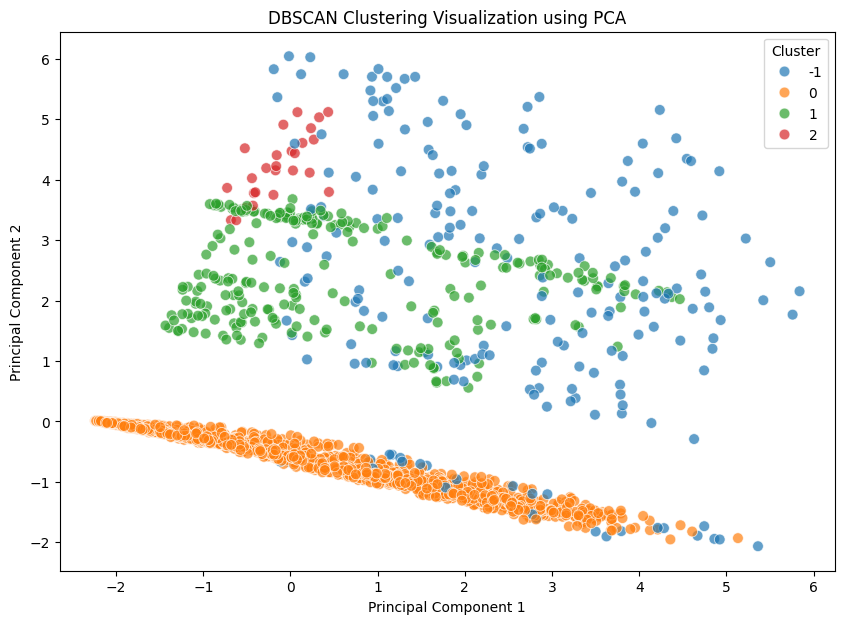

In [34]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_dbscan,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=60,
    alpha=0.7
)
plt.title("DBSCAN Clustering Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [35]:
dbscan_profile = X_dbscan[
    X_dbscan["Cluster"] != -1
].groupby("Cluster")[features].mean()
dbscan_profile.round(2)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
Cluster,,,,,,,,,,
0,43057.77,0.0,1.77,1.0,1.0,9924.95,8.89,0.00,0.0,3881.32
1,47062.22,0.0,1.80,1.0,1.0,10658.43,8.98,337.68,1.0,3906.13
2,28602.33,0.0,1.00,1.0,1.0,1977.19,3.96,350.19,2.0,3223.15


In [36]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Clusters": [3, 3],
    "Silhouette Score": [
        kmeans_silhouette,
        dbscan_silhouette
    ]
})
comparison

,Algorithm,Clusters,Silhouette Score
0,K-Means,3,0.377514
1,DBSCAN,3,0.331485


## Conclusion

In this analysis, customer segmentation was performed on the EastWest Airlines dataset using K-Means and DBSCAN clustering algorithms. The dataset contained 3,999 customer records and 12 variables. The ID column was excluded because it is only an identifier, while the Award column was excluded from clustering because it represents an outcome rather than a customer characteristic.

The data was explored using descriptive statistics, histograms, boxplots, and a correlation heatmap. Several variables showed skewed distributions and extreme values, so the IQR method was used for outlier removal. After preprocessing, the features were standardized using StandardScaler because both K-Means and DBSCAN are distance-based algorithms.

For K-Means, the Elbow Method and Silhouette Score were used to determine a suitable number of clusters. Three clusters provided the best silhouette performance among the tested values, with a silhouette score of approximately 0.378. The resulting clusters represented different customer behavior patterns, including high-value bonus-oriented customers, lower-engagement customers, and customers with greater recent flight activity.

DBSCAN was also applied with different epsilon values and a minimum sample value of 5. An epsilon of approximately 1.1 produced three clusters and identified around 206 observations as noise. The resulting silhouette score was approximately 0.331. DBSCAN was useful for identifying observations that did not belong strongly to any dense customer group.

Overall, K-Means produced a slightly higher silhouette score than DBSCAN for this dataset. Therefore, K-Means provided the stronger clustering solution based on the selected internal evaluation metric. However, DBSCAN provided additional insight by identifying noise observations and does not require the number of clusters to be specified in advance.

The clustering results can be useful for customer segmentation, allowing an airline loyalty program to identify different customer groups and potentially develop targeted marketing, reward, and retention strategies for each segment.
